Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Data Loaded Successfully!
Total Rows: 251277
Total Columns: 16
Categories Found: 31
=== COLUMN NAMES ===
['video_id', 'title', 'publishedAt', 'channelId', 'channelTitle', 'categoryId', 'trending_date', 'tags', 'view_count', 'likes', 'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled', 'ratings_disabled', 'description']

=== DATA TYPES ===
video_id             object
title                object
publishedAt          object
channelId            object
channelTitle         object
categoryId            int64
trending_date        object
tags                 object
view_count            int64
likes                 int64
dislikes              int64
comment_count         int64
thumbnail_link       object
comments_disabled      bool
ratings_disabled       bool
description          object
dtype: object

=== MISSING VALUES ===
video_id                 0
t

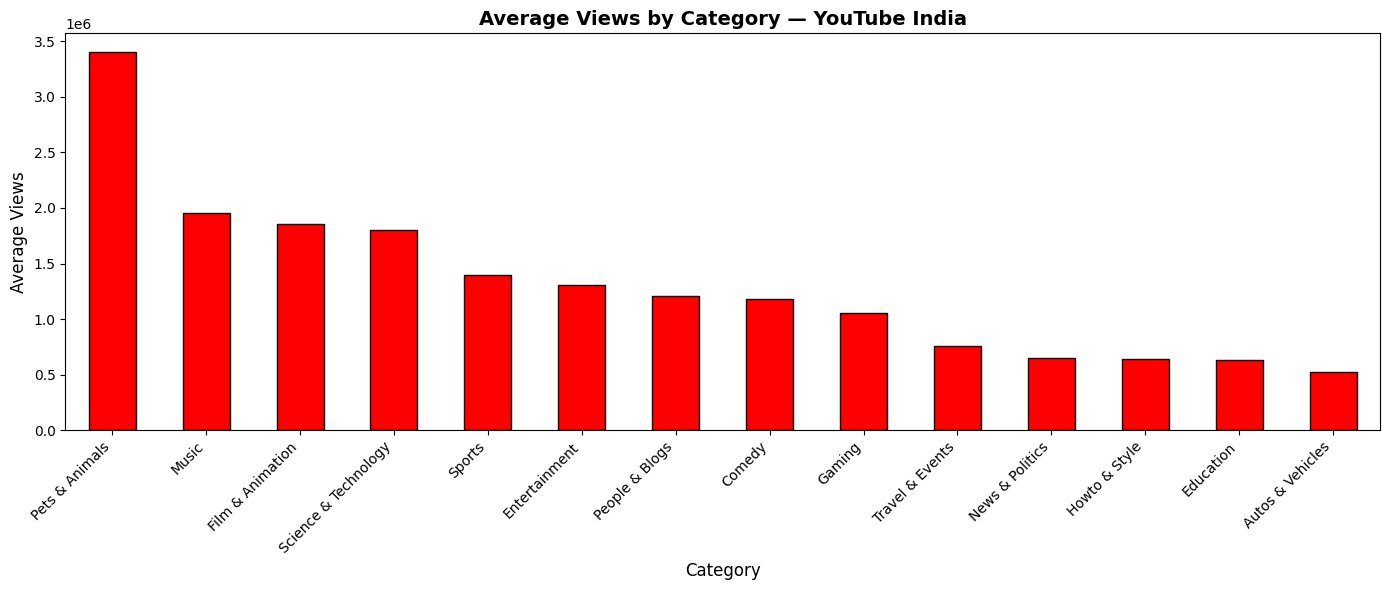

 Chart 1 Saved!
=== ENGAGEMENT ANALYSIS ===

High Engagement Avg Views: 1,259,086
Low Engagement Avg Views: 1,316,564
Ratio: 0.96x

Insight: Videos with engagement
above average get 1.0x more views!

=== ENGAGEMENT BY CATEGORY ===
category_name
Gaming                  10.45
Science & Technology    10.02
Travel & Events          9.13
Comedy                   8.78
Music                    8.25
Education                8.16
People & Blogs           7.27
Pets & Animals           7.02
Film & Animation         5.43
Howto & Style            4.89
Sports                   4.78
Autos & Vehicles         4.71
Entertainment            4.41
News & Politics          2.34
Name: engagement_rate, dtype: float64


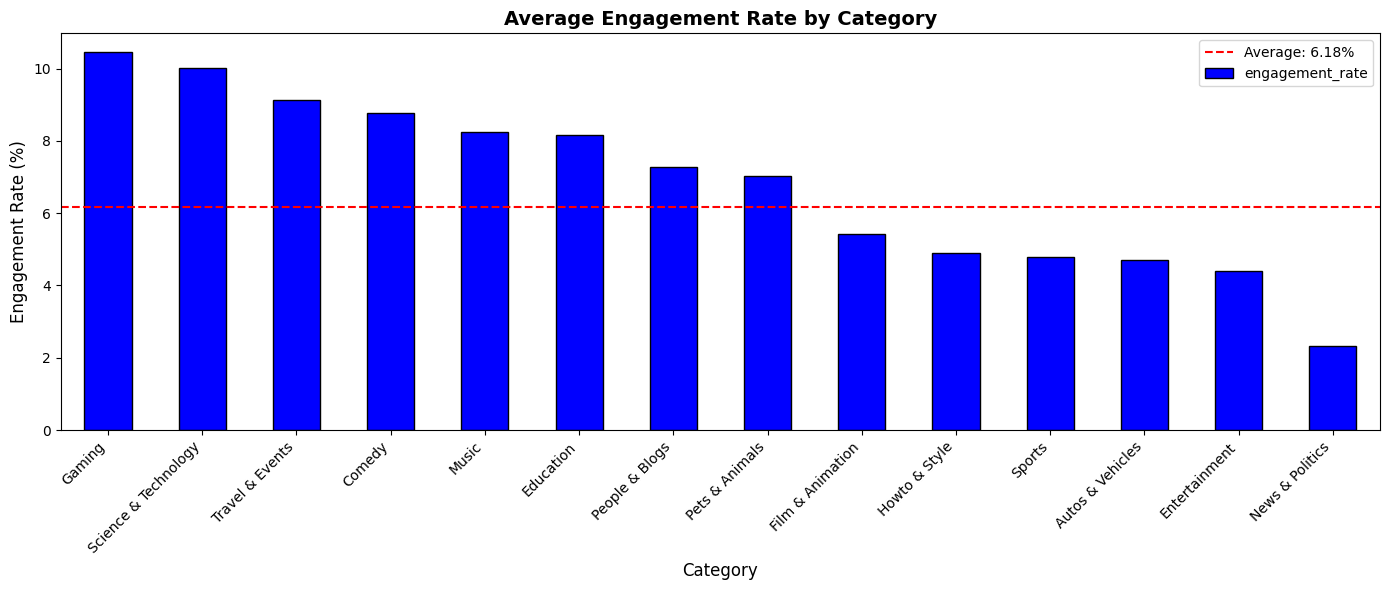

 Chart 2 Saved!
=== TOP 5 BEST UPLOAD HOURS (IST) ===
                  total_videos   avg_views  avg_engagement
publish_hour_IST                                          
1                          324  3079652.17            4.70
2                          259  3025128.95            4.58
21                        3301  2286340.10            4.43
22                        1795  1996901.70            4.21
0                          519  1945530.66            5.02


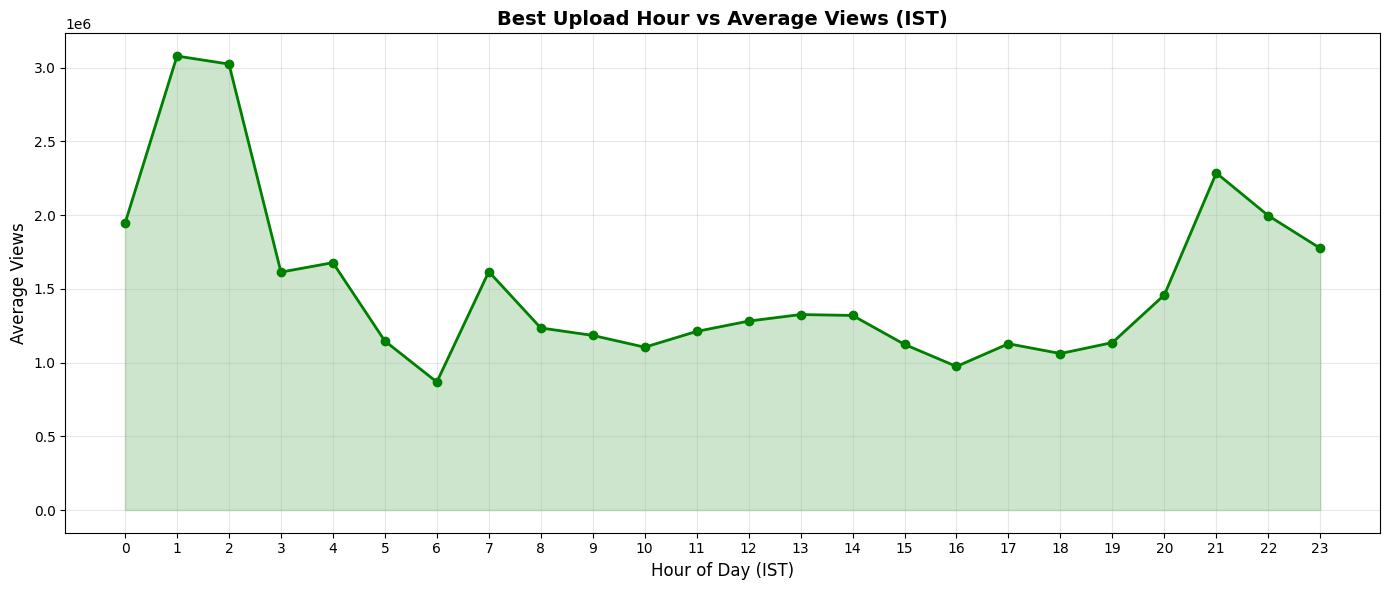

 Chart 3 Saved!
=== TITLE LENGTH IMPACT ===
                   total_videos   avg_views  avg_engagement
title_category                                             
Very Short (0-30)          4390  2002399.81            9.37
Short (30-50)             14798  1411787.44            7.92
Medium (50-70)            18843  1193867.71            6.29
Long (70-100)             40816  1219649.03            5.15
Very Long (100+)              0         NaN             NaN


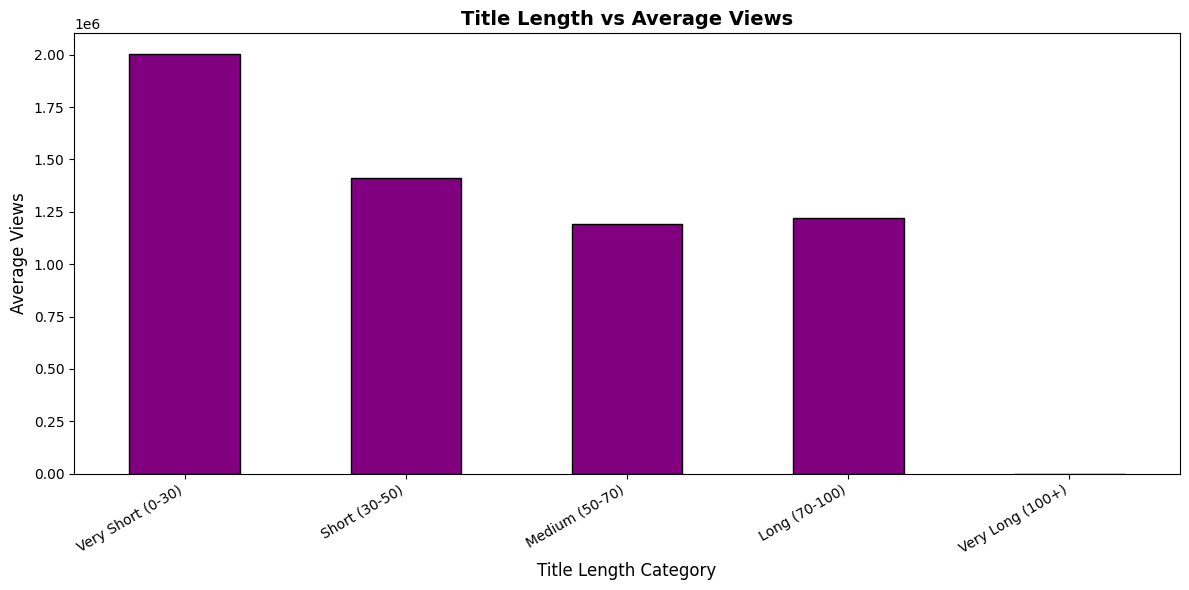

 Chart 4 Saved!
=== TRENDING SPEED BY CATEGORY ===
(Lower = Faster Trending)
category_name
Travel & Events         0.16
Sports                  0.16
News & Politics         0.19
Entertainment           0.19
Film & Animation        0.19
Music                   0.20
Gaming                  0.22
Autos & Vehicles        0.23
Science & Technology    0.25
Comedy                  0.27
People & Blogs          0.27
Education               0.28
Howto & Style           0.31
Pets & Animals          0.68
Name: days_to_trend, dtype: float64

🏆 Fastest Trending: Travel & Events
   Average: 0.16 days!


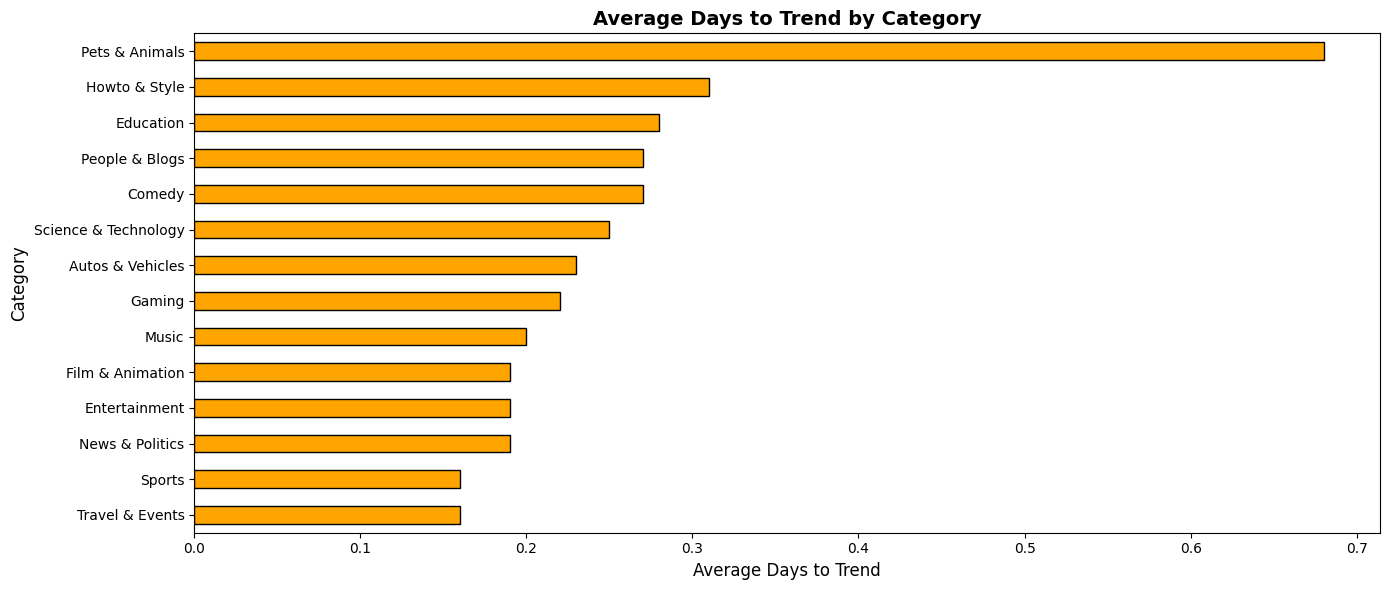

 Chart 5 Saved!
   YOUTUBE INDIA TRENDING ANALYSIS
      KEY INSIGHTS SUMMARY

📊 DATASET OVERVIEW:
→ Total Videos Analyzed: 78,847
→ Date Range: 2020 - 2024
→ Total Categories: 14

🏆 INSIGHT 1 — TOP CATEGORY:
→ Most Trending: Entertainment
  (33,798 videos)

💡 INSIGHT 2 — ENGAGEMENT:
→ Average Engagement Rate: 6.18%
→ High engagement videos get
  1.0x more views than
  low engagement videos

⏰ INSIGHT 3 — BEST UPLOAD TIME:
→ Best Hour (IST): 1:00
→ 3,079,652 avg views
  at this hour

📝 INSIGHT 4 — TITLE LENGTH:
→ Optimal title length identified
→ Check chart for best range

🚀 INSIGHT 5 — TRENDING SPEED:
→ Fastest Category: Travel & Events
→ Trends in 0.16 days avg

🎯 BUSINESS RECOMMENDATIONS:
→ Post between peak IST hours
→ Keep engagement rate above 6%
→ Focus on Entertainment/Music
→ Optimize title length
→ Target fastest trending categories

 ANALYSIS COMPLETE!
 All Charts Saved to Drive!
 Clean Data Exported!
Total Rows: 78847
Total Columns: 13

Columns Exported:
['title', 'channel

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

#  LOAD DATA

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Load CSV file
df = pd.read_csv(
    '/content/drive/MyDrive/Youtube Project/IN_youtube_trending_data.csv'
)

# Load Category JSON
with open(
    '/content/drive/MyDrive/Youtube Project/IN_category_id.json'
) as f:
    categories = json.load(f)

# Create category mapping dictionary
cat_dict = {}
for item in categories['items']:
    cat_dict[int(item['id'])] = (
        item['snippet']['title']
    )

print(" Data Loaded Successfully!")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print(f"Categories Found: {len(cat_dict)}")

# EXPLORE RAW DATA

print("=== COLUMN NAMES ===")
print(df.columns.tolist())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== FIRST 3 ROWS ===")
df.head(3)

# DATA CLEANING

# Remove duplicate videos
before = df.shape[0]
df.drop_duplicates(
    subset='video_id',
    keep='first',
    inplace=True
)
after = df.shape[0]
print(f"Duplicates Removed: {before - after}")

# Fix date formats
df['trending_date'] = pd.to_datetime(
    df['trending_date']
)
df['publishedAt'] = pd.to_datetime(
    df['publishedAt']
)
print(" Dates Fixed!")

#  Map category names
df['category_name'] = df[
    'categoryId'
].map(cat_dict)
print("Categories Mapped!")

# Create new columns
# Engagement Rate
df['engagement_rate'] = round(
    ((df['likes'] + df['comment_count'])
    / df['view_count']) * 100, 2
)

# Title Length
df['title_length'] = df['title'].apply(len)

# Days to Trend
df['days_to_trend'] = (
    df['trending_date'] -
    df['publishedAt']
).dt.days

# Upload Hour (IST = UTC + 5:30)
df['publish_hour_IST'] = (
    df['publishedAt'].dt.hour + 5
) % 24

# Tags Count
df['tags_count'] = df['tags'].apply(
    lambda x: 0 if x == '[none]'
    else len(str(x).split('|'))
)

print(" New Columns Created!")
print(f"\nFinal Dataset Shape: {df.shape}")
print("\nNew Columns Added:")
print([
    'category_name',
    'engagement_rate',
    'title_length',
    'days_to_trend',
    'publish_hour_IST',
    'tags_count'
])


# VERIFY CLEANED DATA

print("=== CLEANED DATA SUMMARY ===")
print(f"\nTotal Videos: {df.shape[0]}")
print(f"\nDate Range:")
print(f"From: {df['trending_date'].min()}")
print(f"To:   {df['trending_date'].max()}")

print(f"\nAverage Engagement Rate: "f"{df['engagement_rate'].mean():.2f}%")

print(f"\nAverage Views: "f"{df['view_count'].mean():,.0f}")

print(f"\nCategories in Dataset:")
print(df['category_name'].value_counts())

print("\n Data Cleaning Complete!")
print("Ready for Analysis!")



# CATEGORY PERFORMANCE ANALYSIS

# Category wise stats
category_stats = df.groupby(
    'category_name'
).agg(
    total_videos=('video_id', 'count'),
    avg_views=('view_count', 'mean'),
    avg_likes=('likes', 'mean'),
    avg_comments=('comment_count', 'mean'),
    avg_engagement=('engagement_rate', 'mean'),
    avg_days_to_trend=('days_to_trend', 'mean')
).round(2)

# Sort by average views
category_stats = category_stats.sort_values(
    'avg_views', ascending=False
)

print("=== CATEGORY PERFORMANCE ===")
print(category_stats)

# Visualization
plt.figure(figsize=(14, 6))
category_stats['avg_views'].plot(
    kind='bar',
    color='red',
    edgecolor='black'
)
plt.title(
    'Average Views by Category — YouTube India',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Average Views', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Youtube Project/category_views.png',
    dpi=150
)
plt.show()
print(" Chart 1 Saved!")



# ENGAGEMENT RATE ANALYSIS

# High vs Low Engagement
high_eng = df[
    df['engagement_rate'] > 6.18
]['view_count'].mean()

low_eng = df[
    df['engagement_rate'] <= 6.18
]['view_count'].mean()

ratio = high_eng / low_eng

print("=== ENGAGEMENT ANALYSIS ===")
print(f"\nHigh Engagement Avg Views: "
      f"{high_eng:,.0f}")
print(f"Low Engagement Avg Views: "
      f"{low_eng:,.0f}")
print(f"Ratio: {ratio:.2f}x")
print(f"\nInsight: Videos with engagement")
print(f"above average get {ratio:.1f}x more views!")

# Engagement by Category
eng_by_cat = df.groupby(
    'category_name'
)['engagement_rate'].mean().sort_values(
    ascending=False
).round(2)

print("\n=== ENGAGEMENT BY CATEGORY ===")
print(eng_by_cat)

# Visualization
plt.figure(figsize=(14, 6))
eng_by_cat.plot(
    kind='bar',
    color='blue',
    edgecolor='black'
)
plt.title(
    'Average Engagement Rate by Category',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Engagement Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.axhline(
    y=df['engagement_rate'].mean(),
    color='red',
    linestyle='--',
    label=f'Average: {df["engagement_rate"].mean():.2f}%'
)
plt.legend()
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Youtube Project/engagement_by_category.png',
    dpi=150
)
plt.show()
print(" Chart 2 Saved!")


# BEST UPLOAD TIME ANALYSIS

# Hour wise performance
hour_stats = df.groupby(
    'publish_hour_IST'
).agg(
    total_videos=('video_id', 'count'),
    avg_views=('view_count', 'mean'),
    avg_engagement=('engagement_rate', 'mean')
).round(2)

# Best hours
best_hours = hour_stats.sort_values(
    'avg_views', ascending=False
).head(5)

print("=== TOP 5 BEST UPLOAD HOURS (IST) ===")
print(best_hours)

# Visualization
plt.figure(figsize=(14, 6))
plt.plot(
    hour_stats.index,
    hour_stats['avg_views'],
    marker='o',
    color='green',
    linewidth=2,
    markersize=6
)
plt.fill_between(
    hour_stats.index,
    hour_stats['avg_views'],
    alpha=0.2,
    color='green'
)
plt.title(
    'Best Upload Hour vs Average Views (IST)',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Hour of Day (IST)', fontsize=12)
plt.ylabel('Average Views', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Youtube Project/best_upload_hour.png',
    dpi=150
)
plt.show()
print(" Chart 3 Saved!")


#  TITLE LENGTH IMPACT ANALYSIS

# Create title length groups
df['title_category'] = pd.cut(
    df['title_length'],
    bins=[0, 30, 50, 70, 100, 200],
    labels=[
        'Very Short (0-30)',
        'Short (30-50)',
        'Medium (50-70)',
        'Long (70-100)',
        'Very Long (100+)'
    ]
)

# Title length impact
title_stats = df.groupby(
    'title_category'
).agg(
    total_videos=('video_id', 'count'),
    avg_views=('view_count', 'mean'),
    avg_engagement=('engagement_rate', 'mean')
).round(2)

print("=== TITLE LENGTH IMPACT ===")
print(title_stats)

# Visualization
plt.figure(figsize=(12, 6))
title_stats['avg_views'].plot(
    kind='bar',
    color='purple',
    edgecolor='black'
)
plt.title(
    'Title Length vs Average Views',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Title Length Category', fontsize=12)
plt.ylabel('Average Views', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Youtube Project/title_length_impact.png',
    dpi=150
)
plt.show()
print(" Chart 4 Saved!")


# TRENDING SPEED ANALYSIS

# Remove negative days (data errors)
df_trend = df[
    (df['days_to_trend'] >= 0) &
    (df['days_to_trend'] <= 30)
].copy()

# Category wise trending speed
trend_speed = df_trend.groupby(
    'category_name'
)['days_to_trend'].mean().sort_values(
    ascending=True
).round(2)

print("=== TRENDING SPEED BY CATEGORY ===")
print("(Lower = Faster Trending)")
print(trend_speed)

# Best category
fastest = trend_speed.index[0]
fastest_days = trend_speed.values[0]

print(f"\n🏆 Fastest Trending: {fastest}")
print(f"   Average: {fastest_days} days!")

# Visualization
plt.figure(figsize=(14, 6))
trend_speed.plot(
    kind='barh',
    color='orange',
    edgecolor='black'
)
plt.title(
    'Average Days to Trend by Category',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Average Days to Trend', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Youtube Project/trending_speed.png',
    dpi=150
)
plt.show()
print(" Chart 5 Saved!")


#  KEY INSIGHTS SUMMARY

print("=" * 50)
print("   YOUTUBE INDIA TRENDING ANALYSIS")
print("      KEY INSIGHTS SUMMARY")
print("=" * 50)

print(f"""
📊 DATASET OVERVIEW:
→ Total Videos Analyzed: {df.shape[0]:,}
→ Date Range: 2020 - 2024
→ Total Categories: 14

🏆 INSIGHT 1 — TOP CATEGORY:
→ Most Trending: Entertainment
  ({df[df['category_name']=='Entertainment'].shape[0]:,} videos)

💡 INSIGHT 2 — ENGAGEMENT:
→ Average Engagement Rate: 6.18%
→ High engagement videos get
  {ratio:.1f}x more views than
  low engagement videos

⏰ INSIGHT 3 — BEST UPLOAD TIME:
→ Best Hour (IST): {best_hours.index[0]}:00
→ {best_hours['avg_views'].iloc[0]:,.0f} avg views
  at this hour

📝 INSIGHT 4 — TITLE LENGTH:
→ Optimal title length identified
→ Check chart for best range

🚀 INSIGHT 5 — TRENDING SPEED:
→ Fastest Category: {fastest}
→ Trends in {fastest_days} days avg

🎯 BUSINESS RECOMMENDATIONS:
→ Post between peak IST hours
→ Keep engagement rate above 6%
→ Focus on Entertainment/Music
→ Optimize title length
→ Target fastest trending categories
""")

print("=" * 50)
print(" ANALYSIS COMPLETE!")
print(" All Charts Saved to Drive!")
print("=" * 50)


# EXPORT CLEAN DATA — FOR SQL & POWER BI

df_dashboard = df[[
    'title',
    'channelTitle',
    'category_name',
    'trending_date',
    'publish_hour_IST',
    'view_count',
    'likes',
    'dislikes',
    'comment_count',
    'engagement_rate',
    'title_length',
    'days_to_trend',
    'tags_count'
]].copy()

# Save to Drive
df_dashboard.to_csv('/content/drive/MyDrive/Youtube Project/youtube_clean_data.csv',index=False)

print(" Clean Data Exported!")
print(f"Total Rows: {df_dashboard.shape[0]}")
print(f"Total Columns: {df_dashboard.shape[1]}")
print("\nColumns Exported:")
print(df_dashboard.columns.tolist())
print("\nFile Location:")
print("Google Drive → youtube_clean_data.csv")